In [16]:
import numpy as np
import mogptk
# Synthetic data
N = 120
X = np.random.rand(N, 1)

t1 = np.sin(2 * np.pi * X)
t2 = np.cos(2 * np.pi * X)
t3 = -np.sin(2 * np.pi * X)
t_all = np.concatenate((t1, t2, t3), axis=1)
# labels = class with highest value
T = np.hstack([t1, t2, t3])  # shape (N, 3)
y = np.argmax(T, axis=1).reshape(-1,1)  # shape (N,1), values 0-1-2


In [2]:
print("Shapes:")
print("X:", X.shape)
print("y:", y.shape)
print("Classes present:", np.unique(y))

Shapes:
X: (120, 1)
y: (120, 1)
Classes present: [0 1 2]


<Axes: title={'center': '3 canales (t1,t2,t3)'}, xlabel='X', ylabel='Y'>

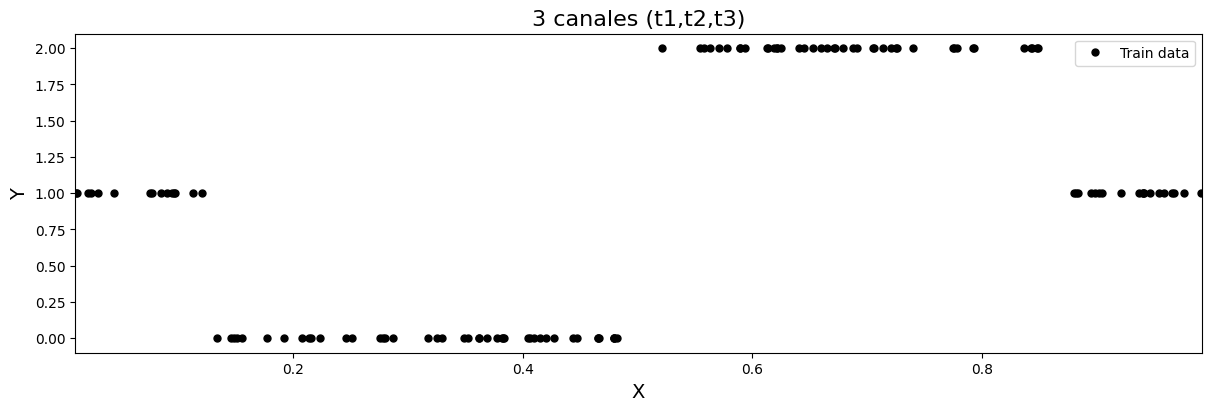

In [3]:
# Build dataset
data = mogptk.DataSet(
    mogptk.Data(X, y, name="Classification data 1"),
    mogptk.Data(X, y, name="Classification data 2"),
    mogptk.Data(X, y, name="Classification data 3")
)

data[0].plot(title="3 canales (t1,t2,t3)")


In [4]:
# Instanciar likelihood
K = 3

In [5]:
likelihood = mogptk.gpr.MultiLatentLikelihood(
    mogptk.gpr.SoftmaxLikelihood(num_classes=K)
)

In [6]:
kernels = [
    mogptk.gpr.SquaredExponentialKernel(),
    mogptk.gpr.SquaredExponentialKernel(),
    mogptk.gpr.SquaredExponentialKernel()
]

kernel = mogptk.gpr.IndependentMultiOutputKernel(*kernels)

In [7]:
inference = mogptk.Hensman(likelihood=likelihood)

In [8]:
# 4. Model
model = mogptk.Model(data, kernel, inference=inference)

In [9]:
print(model.gpr.q_mu().shape)
print(model.gpr.q_sqrt().shape)

torch.Size([360, 1])
torch.Size([360, 360])


Starting optimization using Adam
‣ Model: Hensman
  ‣ Kernel: IndependentMultiOutputKernel[SquaredExponentialKernel,SquaredExponentialKernel,SquaredExponentialKernel]
  ‣ Likelihood: MultiLatent[SoftmaxLikelihood, Q=3]
‣ Channels: 3
‣ Parameters: 65346
‣ Training points: 360
‣ Iterations: 1000


C:\Users\Usuario UTP\Documents\Doctorado\mogptk\mogptk\model.py:384: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  return float(self.gpr.loss())


     0/1000   0:00:01  loss=      172.56 (warmup)
   503/1000   0:00:10  loss=     78.7052
  1000/1000   0:00:17  loss=     44.7662
Optimization finished in 17.913 seconds


(<Figure size 1200x400 with 1 Axes>, <Axes: xlabel='Iteration', ylabel='Loss'>)

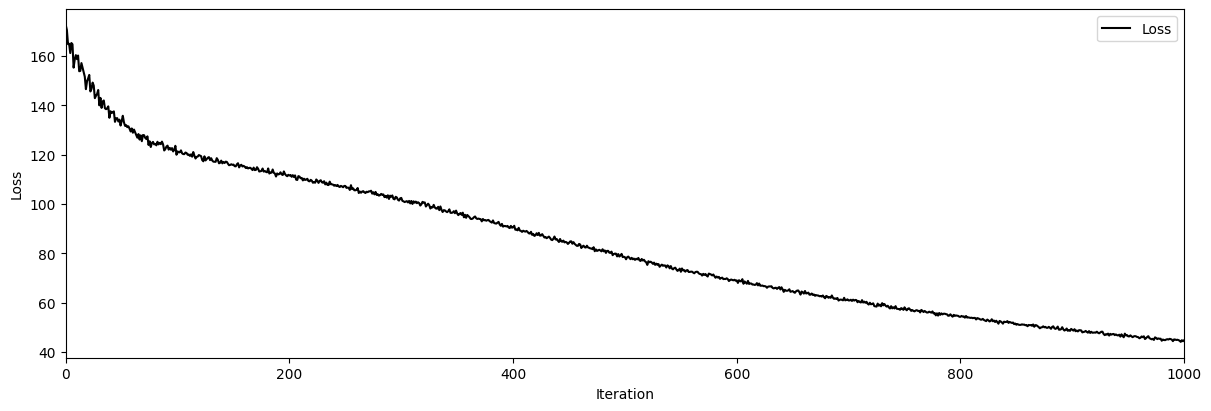

In [10]:
model.train(iters=1000, verbose=True, lr=0.01)
model.plot_losses()

(<Figure size 1200x1200 with 3 Axes>,
 array([[<Axes: title={'center': 'Predicción del modelo entrenado'}, xlabel='X', ylabel='Y'>],
        [<Axes: title={'center': 'Predicción del modelo entrenado'}, xlabel='X', ylabel='Y'>],
        [<Axes: title={'center': 'Predicción del modelo entrenado'}, xlabel='X', ylabel='Y'>]],
       dtype=object))

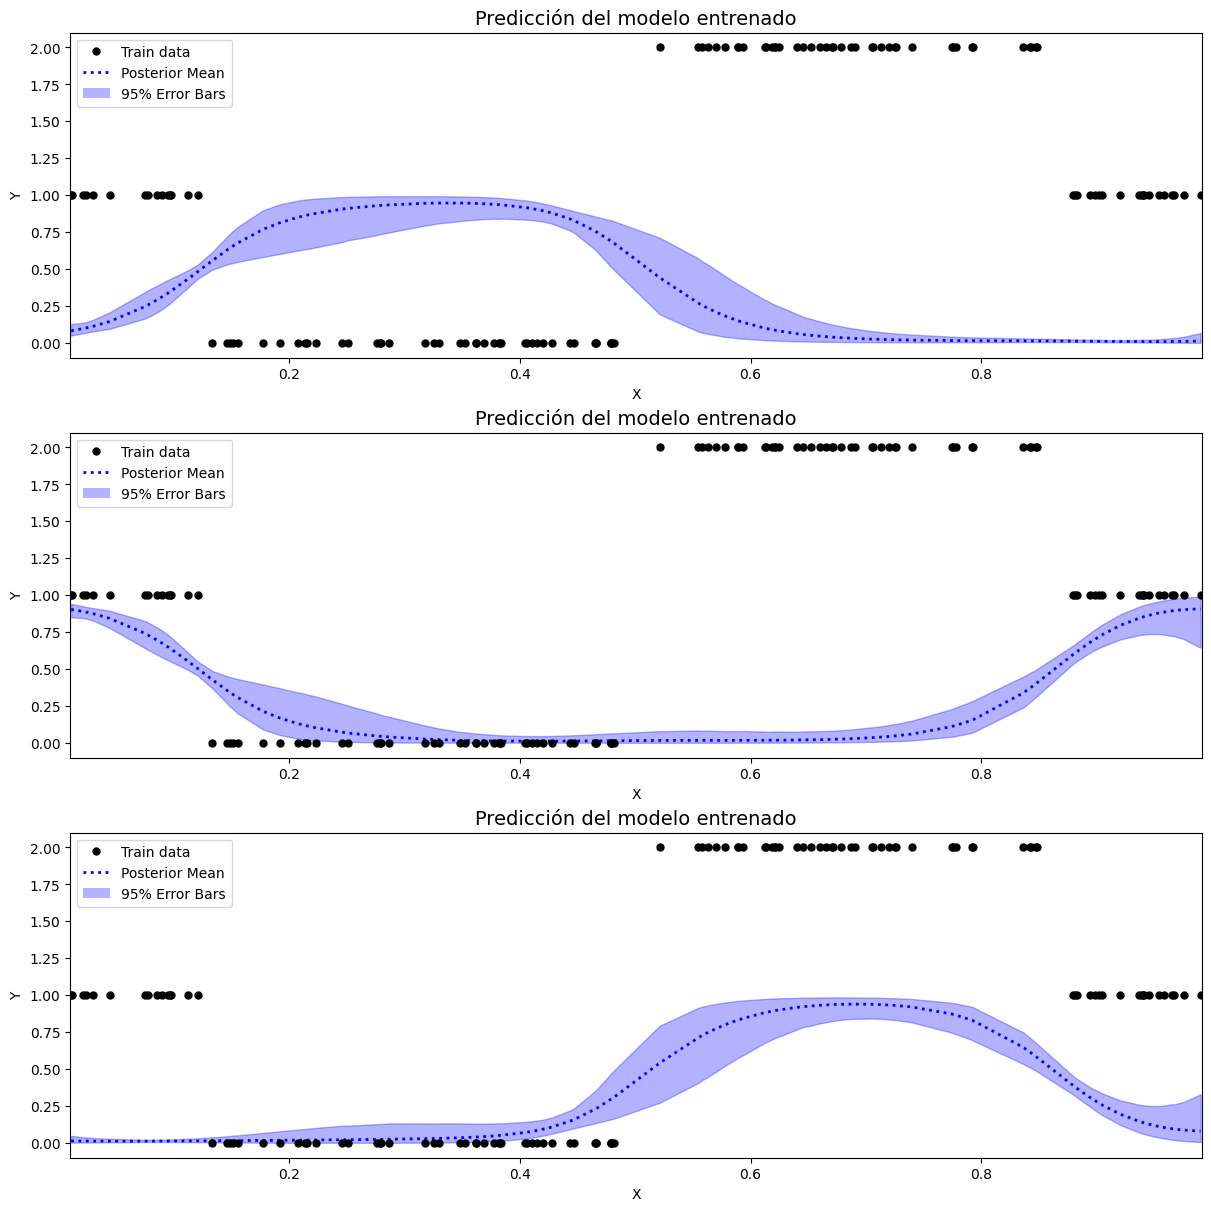

In [11]:
model.plot_prediction(n=100000, title="Predicción del modelo entrenado")

Detected: softmax with K=3 classes


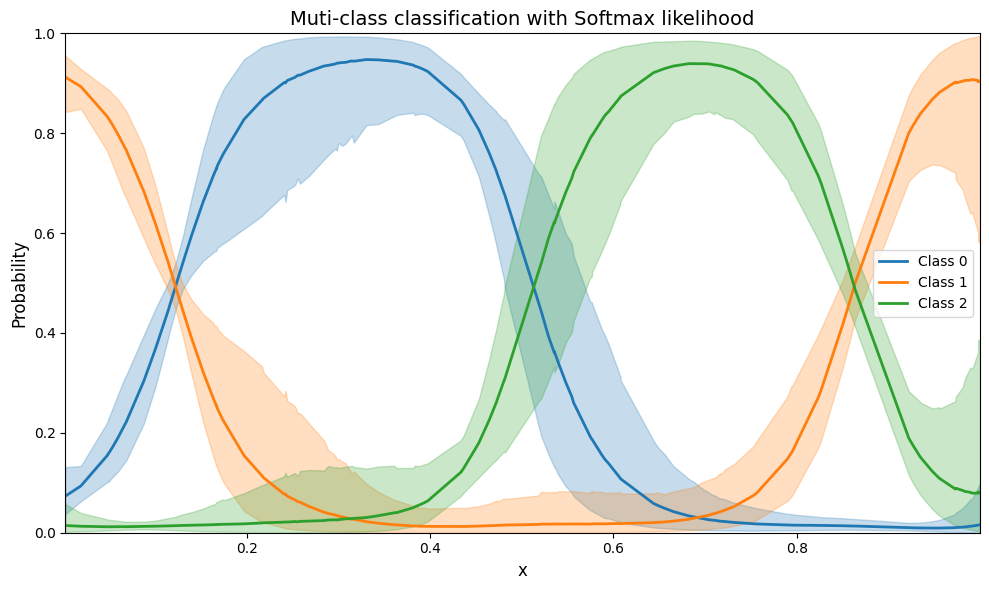

In [17]:
# Para Softmax
fig = mogptk.model.plot_multilatent_prediction(
    model=model,
    X_train=X,
    Y_train=y,
    X_test=X,
    sigma=2,
    title='Muti-class classification with Softmax likelihood'
)